In [1]:
import polars as pl
import polars.selectors as cs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


# Core ML Libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, LabelEncoder, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_regression, RFE, SelectFromModel, VarianceThreshold
from sklearn.decomposition import PCA, TruncatedSVD, FastICA, FactorAnalysis
from sklearn.manifold import TSNE, Isomap
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Advanced ML Models
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor,
                             AdaBoostRegressor, ExtraTreesRegressor, VotingRegressor, BaggingRegressor)
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge,
                                 HuberRegressor, TheilSenRegressor, RANSACRegressor)
from sklearn.svm import SVR, SVC, NuSVR
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.neural_network import MLPRegressor

# XGBoost and LightGBM
try:
    import xgboost as xgb
    HAS_XGB = True
except:
    HAS_XGB = False

try:
    import lightgbm as lgb
    HAS_LGB = True
except:
    HAS_LGB = False

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l1, l2, l1_l2

# Advanced Metrics
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error, median_absolute_error,
                            explained_variance_score, max_error, mean_squared_log_error,
                            silhouette_score, adjusted_rand_score, accuracy_score, classification_report, confusion_matrix)

# Statistical Analysis
from scipy import stats
from scipy.stats import (chi2_contingency, pearsonr, spearmanr, normaltest, shapiro,
                         anderson, jarque_bera, kstest, alpha)
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [2]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (20, 12)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#FFB347', '#87CEEB']
sns.set_palette(colors)

In [3]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [4]:
df_path = r"D:\Datasets\Data Preaparations\academic Stress level - maintainance 1.csv"

In [5]:
df = pl.read_csv(df_path)

In [6]:
print(f"✅ Dataset loaded successfully!")
print(f"   📈 Dataset shape: {df.shape}")
print(f"   📋 Memory usage: {df.estimated_size('kb'):.2f} KB")

null_counts = df.null_count().sum_horizontal()
duplicate_counts = df.is_duplicated().sum()

print(f'   🔍 Missing values: {null_counts[0]}')
print(f'   🔄 Duplicate records:: {duplicate_counts}')
print(f"      - Numeric: {df.select(cs.numeric()).width}")
print(f"      - Object: {df.select(cs.string()).width}")

✅ Dataset loaded successfully!
   📈 Dataset shape: (140, 9)
   📋 Memory usage: 16.08 KB
   🔍 Missing values: 1
   🔄 Duplicate records:: 0
      - Numeric: 4
      - Object: 5


In [7]:
df.collect_schema()

Schema([('Timestamp', String),
        ('Your Academic Stage', String),
        ('Peer pressure', Int64),
        ('Academic pressure from your home', Int64),
        ('Study Environment', String),
        ('What coping strategy you use as a student?', String),
        ('Do you have any bad habits like smoking, drinking on a daily basis?',
         String),
        ('What would you rate the academic  competition in your student life',
         Int64),
        ('Rate your academic stress index ', Int64)])

In [8]:
new_columns = {col: col.strip()
                .replace(' ', '_')
                .replace('?', '')
                .replace(',', '')
                .replace('(', '')
                .replace(')', '')
                for col in df.columns
}

column_mapping = {
    df.columns[0]: 'Timestamp',
    df.columns[1]: 'Academic_Stage',
    df.columns[2]: 'Peer_Pressure',
    df.columns[3]: 'Academic_Pressure_Home',
    df.columns[4]: 'Study_Environment',
    df.columns[5]: 'Coping_Strategy',
    df.columns[6]: 'Bad_Habits',
    df.columns[7]: 'Academic_Competition',
    df.columns[8]: 'Stress_Index'
}

df = df.rename(column_mapping)

In [9]:
df

Timestamp,Academic_Stage,Peer_Pressure,Academic_Pressure_Home,Study_Environment,Coping_Strategy,Bad_Habits,Academic_Competition,Stress_Index
str,str,i64,i64,str,str,str,i64,i64
"""24/07/2025 22:05:39""","""undergraduate""",4,5,"""Noisy""","""Analyze the situation and hand…","""No""",3,5
"""24/07/2025 22:05:52""","""undergraduate""",3,4,"""Peaceful""","""Analyze the situation and hand…","""No""",3,3
"""24/07/2025 22:06:39""","""undergraduate""",1,1,"""Peaceful""","""Social support (friends, famil…","""No""",2,4
"""24/07/2025 22:06:45""","""undergraduate""",3,2,"""Peaceful""","""Analyze the situation and hand…","""No""",4,3
"""24/07/2025 22:08:06""","""undergraduate""",3,3,"""Peaceful""","""Analyze the situation and hand…","""No""",4,5
…,…,…,…,…,…,…,…,…
"""17/08/2025 13:02:04""","""undergraduate""",3,2,"""Peaceful""","""Analyze the situation and hand…","""No""",3,4
"""18/08/2025 14:36:00""","""undergraduate""",4,2,"""disrupted""","""Analyze the situation and hand…","""No""",3,3
"""18/08/2025 17:13:52""","""undergraduate""",3,3,"""Peaceful""","""Analyze the situation and hand…","""No""",2,4


In [10]:
df = df.with_columns(
    pl.col('Timestamp').str.strptime(pl.Datetime, '%d/%m/%Y %H:%M:%S').alias('Timestamp'),
    pl.col('Timestamp').str.strptime(pl.Datetime, '%d/%m/%Y %H:%M:%S').dt.hour().alias('Hour'),
    pl.col('Timestamp').str.strptime(pl.Datetime, '%d/%m/%Y %H:%M:%S').dt.day().alias('Day'),
    pl.col('Timestamp').str.strptime(pl.Datetime, '%d/%m/%Y %H:%M:%S').dt.month().alias('Month'),
    pl.col('Timestamp').str.strptime(pl.Datetime, '%d/%m/%Y %H:%M:%S').dt.weekday().alias('Weekday'),
).with_columns(
    pl.when((pl.col('Hour') >= 22) | (pl.col('Hour') <= 6))
    .then(1)
    .otherwise(0)
    .alias('isNight'),

    pl.when(pl.col('Hour').is_between(0, 5, closed='both'))
    .then(pl.lit('Night'))
    .when(pl.col('Hour').is_between(6, 11, closed='both'))
    .then(pl.lit('Morning'))
    .when(pl.col('Hour').is_between(12, 17, closed='both'))
    .then(pl.lit('Afternoon'))
    .when(pl.col('Hour').is_between(18, 23, closed='both'))
    .then(pl.lit('Evening'))
    .otherwise(pl.lit('Night'))
    .alias('Time_of_Day'),
)

In [11]:
df

Timestamp,Academic_Stage,Peer_Pressure,Academic_Pressure_Home,Study_Environment,Coping_Strategy,Bad_Habits,Academic_Competition,Stress_Index,Hour,Day,Month,Weekday,isNight,Time_of_Day
datetime[μs],str,i64,i64,str,str,str,i64,i64,i8,i8,i8,i8,i32,str
2025-07-24 22:05:39,"""undergraduate""",4,5,"""Noisy""","""Analyze the situation and hand…","""No""",3,5,22,24,7,4,1,"""Evening"""
2025-07-24 22:05:52,"""undergraduate""",3,4,"""Peaceful""","""Analyze the situation and hand…","""No""",3,3,22,24,7,4,1,"""Evening"""
2025-07-24 22:06:39,"""undergraduate""",1,1,"""Peaceful""","""Social support (friends, famil…","""No""",2,4,22,24,7,4,1,"""Evening"""
2025-07-24 22:06:45,"""undergraduate""",3,2,"""Peaceful""","""Analyze the situation and hand…","""No""",4,3,22,24,7,4,1,"""Evening"""
2025-07-24 22:08:06,"""undergraduate""",3,3,"""Peaceful""","""Analyze the situation and hand…","""No""",4,5,22,24,7,4,1,"""Evening"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2025-08-17 13:02:04,"""undergraduate""",3,2,"""Peaceful""","""Analyze the situation and hand…","""No""",3,4,13,17,8,7,0,"""Afternoon"""
2025-08-18 14:36:00,"""undergraduate""",4,2,"""disrupted""","""Analyze the situation and hand…","""No""",3,3,14,18,8,1,0,"""Afternoon"""
2025-08-18 17:13:52,"""undergraduate""",3,3,"""Peaceful""","""Analyze the situation and hand…","""No""",2,4,17,18,8,1,0,"""Afternoon"""


In [12]:
df = df.with_columns(
    pl.col('Study_Environment').fill_null('Unknown')
)

In [13]:
import polars as pl
import polars.selectors as cs

label_encoders = {}
freq_encoders = {}

categorical_cols = df.select(cs.string()).columns
encoding_expressions = []

for col in categorical_cols:
    s = df.get_column(col).cast(pl.Utf8)

    unique_vals = s.drop_nulls().unique().sort()
    label_map = {val: idx for idx, val in enumerate(unique_vals.to_list())}
    label_encoders[col] = label_map

    encoding_expressions.append(
        pl.col(col).cast(pl.Utf8).replace(label_map, default=None).alias(f"{col}_Encoded")
    )

    encoding_expressions.append(
        pl.len().over(pl.col(col)).alias(f"{col}_Frequency")
    )

df_encoded = df.with_columns(*encoding_expressions)

In [20]:
df_pandas = df_encoded


📈 STEP 3: ULTRA-COMPREHENSIVE EXPLORATORY DATA ANALYSIS
--------------------------------------------------------------------------------
Creating Figure 1: Advanced Distribution Analysis Matrix...


((array([0.26785714, 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.40178571, 0.        , 0.        , 0.        ,
         0.        , 0.        , 1.60714286, 0.        , 0.        ,
         0.        , 0.        , 0.        , 2.5       , 0.        ,
         0.        , 0.        , 0.        , 0.        , 1.47321429]),
  array([1.  , 1.16, 1.32, 1.48, 1.64, 1.8 , 1.96, 2.12, 2.28, 2.44, 2.6 ,
         2.76, 2.92, 3.08, 3.24, 3.4 , 3.56, 3.72, 3.88, 4.04, 4.2 , 4.36,
         4.52, 4.68, 4.84, 5.  ]),
  <BarContainer object of 25 artists>),)

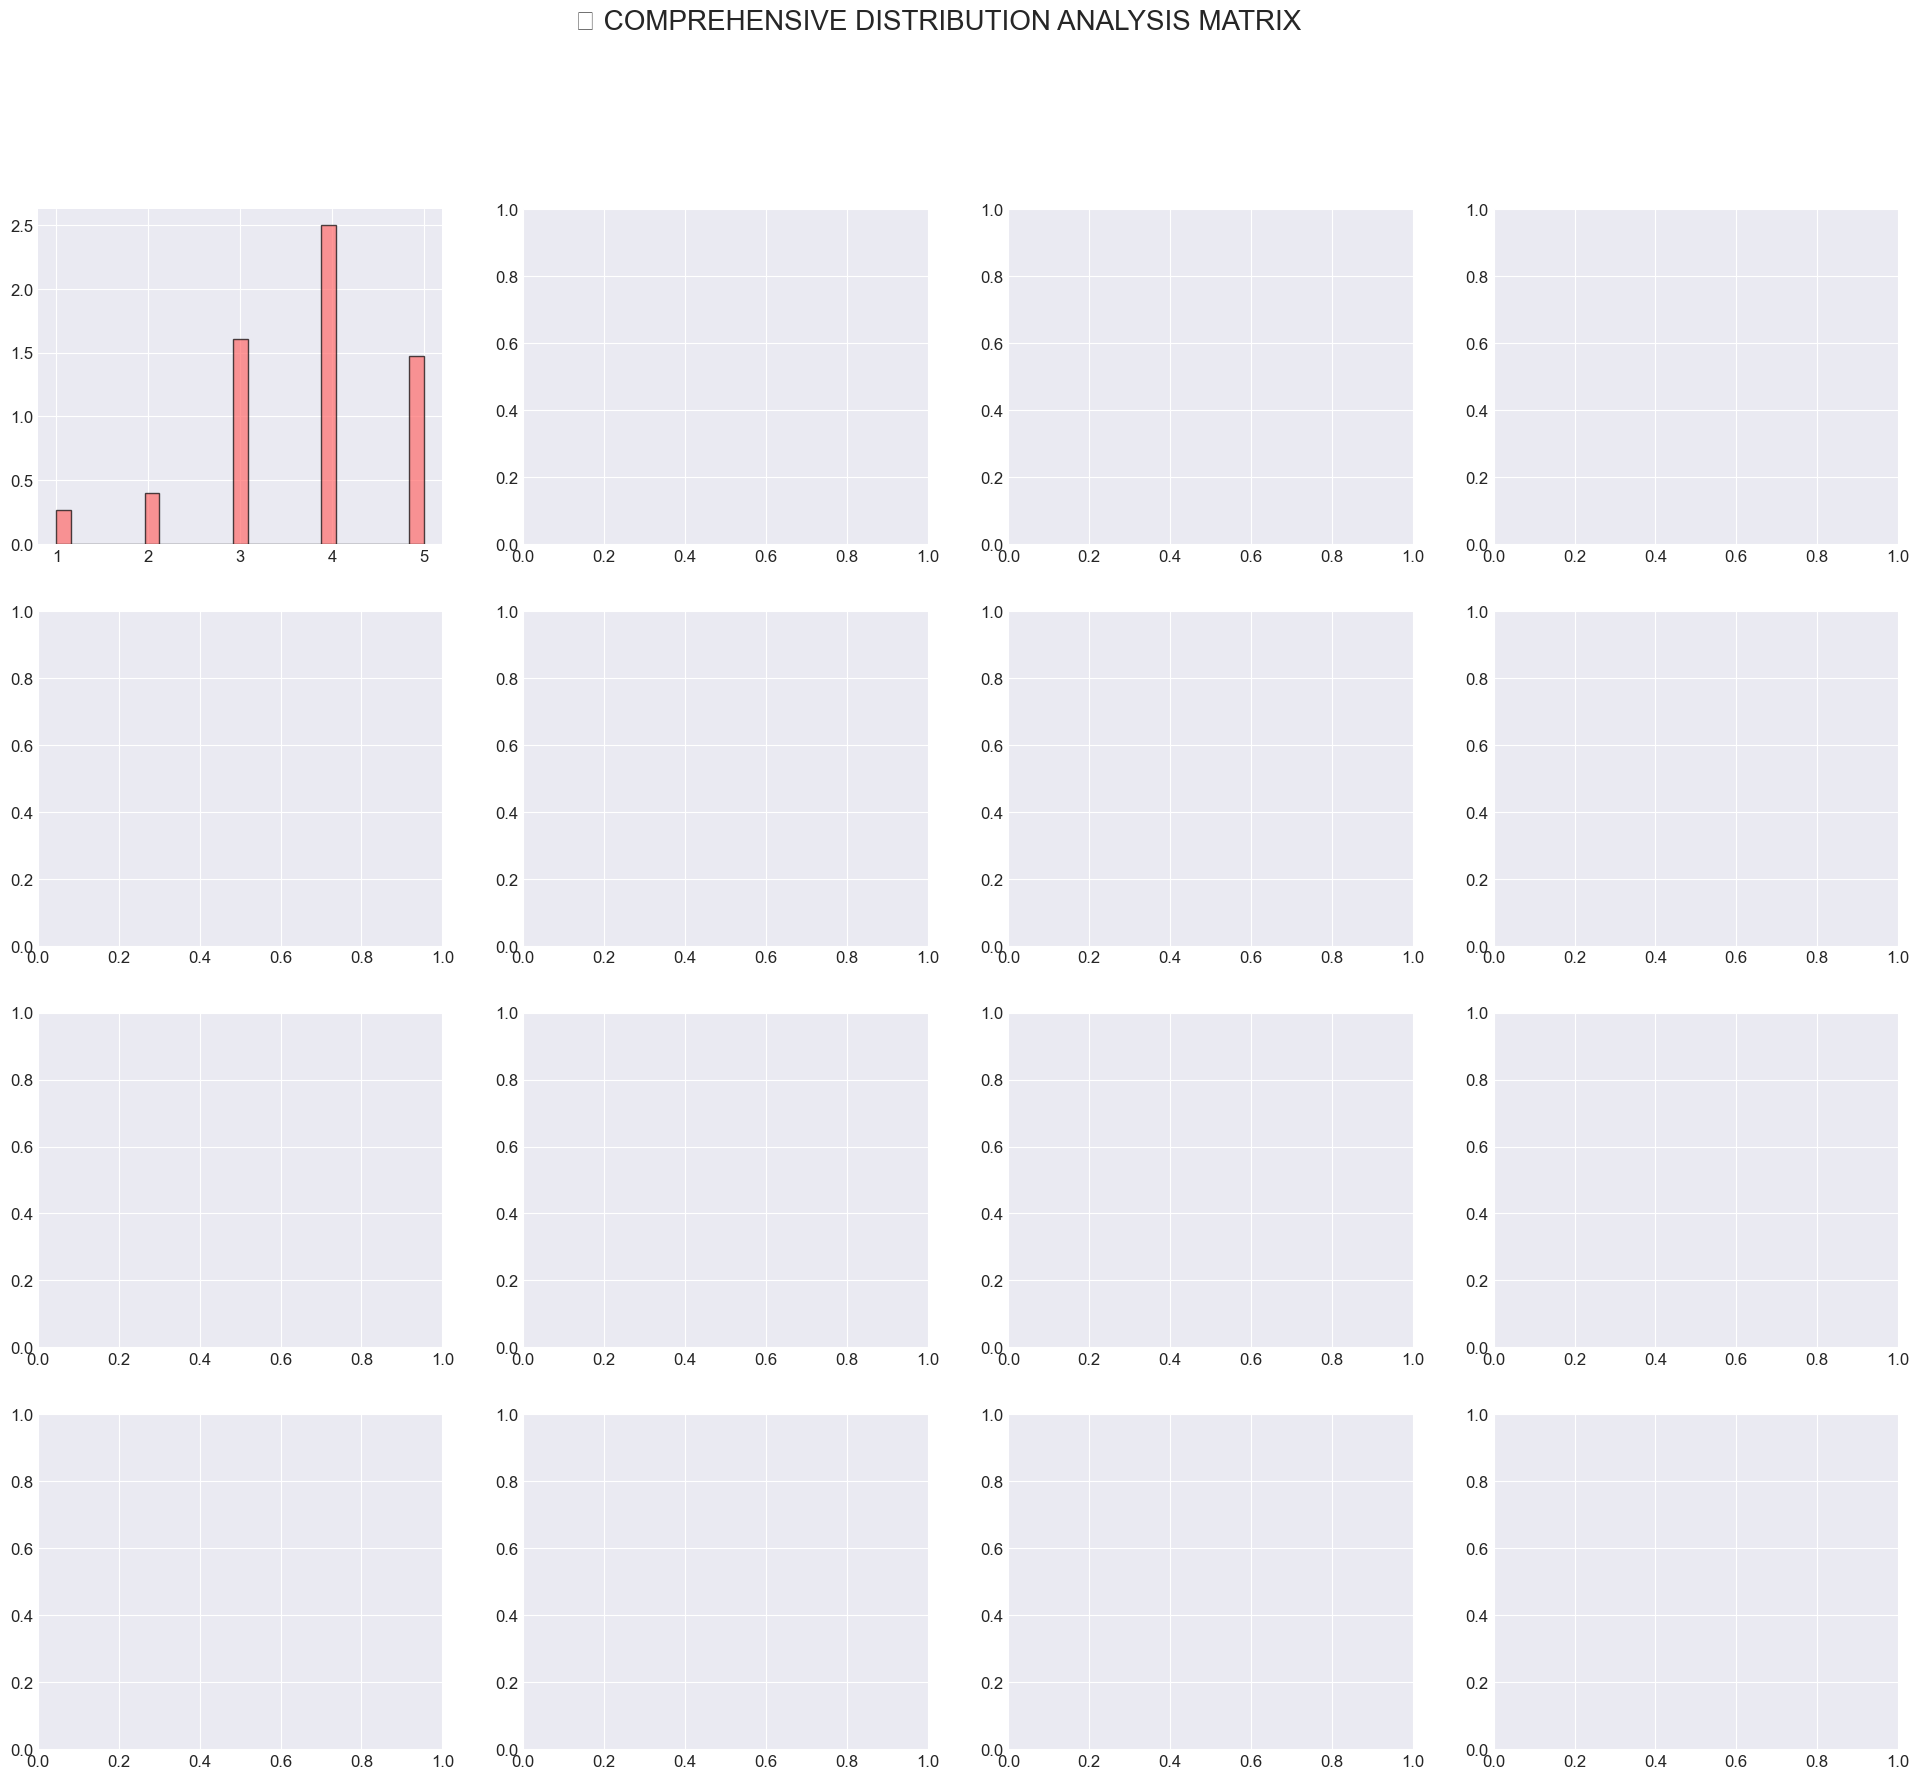

In [22]:
print("\n📈 STEP 3: ULTRA-COMPREHENSIVE EXPLORATORY DATA ANALYSIS")
print("-"*80)

print("Creating Figure 1: Advanced Distribution Analysis Matrix...")
fig, axes = plt.subplots(4, 4, figsize=(24, 20))
fig.suptitle('🎯 COMPREHENSIVE DISTRIBUTION ANALYSIS MATRIX', fontsize=20, y=0.98)

ax = axes[0,0]
ax.hist(df['Stress_Index'], bins=25, alpha=0.7, color=colors[0], edgecolor='black', density=True),
